# HMM with BIO Tagging and POS

This notebook implements an alternative Hidden Markov Model that incorporates:
1. BIO tagging
2. Part-of-Speech (POS)

For detecting negation and uncertainty markers in multilingual Spanish and Catalan medical texts

- Load the preprocessed data with BIO tagging and POS
- Train the enhanced HMM model
- Evaluate performance on test data
- Compare with the baseline model
- Save the model and results


## Imports and Setup


In [1]:
import os
import sys
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

sys.path.append("..")

from src.hmm import HMMBIOPOS
from src.evaluation import *
from utils.analysis import *

PATH_ROOT = os.path.dirname(os.getcwd()) 

os.makedirs(os.path.join(PATH_ROOT, "data_hmm", "results", "models"), exist_ok=True) 
os.makedirs(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation"), exist_ok=True)

np.random.seed(42) 

## Load Preprocessed Data


In [2]:
def load_processed_data(file_path):
    """Load preprocessed data from pickle file"""
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data

train_file = os.path.join(PATH_ROOT, "data_hmm", "processed", "train_bio_pos.pkl")
test_file = os.path.join(PATH_ROOT, "data_hmm", "processed", "test_bio_pos.pkl")

train_data = load_processed_data(train_file) 
test_data = load_processed_data(test_file)

print(f"Loaded {len(train_data['observations'])} training sequences")
print(f"Loaded {len(test_data['observations'])} test sequences")
print(f"Vocabulary size: {len(train_data['vocabulary'])}")
print(f"State space (BIO format): {train_data['state_space']}")

tag_counts = {} # Check BIO tag distribution
for state_seq in train_data["states"]:
    for state in state_seq:
        if state not in tag_counts:
            tag_counts[state] = 0
        tag_counts[state] += 1

print("\nBIO Tag Distribution (Training):")
for tag, count in sorted(tag_counts.items()):
    print(f"  {tag}: {count} tokens")

Loaded 254 training sequences
Loaded 64 test sequences
Vocabulary size: 25318
State space (BIO format): {'B-NSCO', 'B-UNC', 'I-UNC', 'B-USCO', 'I-NEG', 'I-NSCO', 'I-USCO', 'O', 'B-NEG'}

BIO Tag Distribution (Training):
  B-NEG: 4291 tokens
  B-NSCO: 4101 tokens
  B-UNC: 458 tokens
  B-USCO: 451 tokens
  I-NEG: 91 tokens
  I-NSCO: 8561 tokens
  I-UNC: 220 tokens
  I-USCO: 1315 tokens
  O: 165149 tokens


## Train HMM Model


In [3]:
bio_vocabulary = set()
for obs_seq in train_data["observations"]:
    for obs in obs_seq:
        if isinstance(obs, tuple) and len(obs) == 2:
            bio_vocabulary.add(obs)  # Add word-POS tuple to vocabulary

bio_pos_model = HMMBIOPOS( # Initialize and train the BIO+POS enhanced HMM model
    state_space=train_data["state_space"],
    vocabulary=bio_vocabulary,
    smoothing=0.01
)

print("Training BIO+POS enhanced HMM model...")
bio_pos_model.train(train_data["observations"], train_data["states"])  # Train the model

model_path = os.path.join(PATH_ROOT, "data_hmm", "results", "models", "hmm_bio_pos.pkl")  # Path for saving model
bio_pos_model.save(model_path)  # Save the trained model
print(f"Model saved to {model_path}")

Training BIO+POS enhanced HMM model...
Model saved to /home/tomiock/uni2024/natural_language_processing/projectNLP/hidden_markov_models/data_hmm/results/models/hmm_bio_pos.pkl


## Evaluate the Model


In [4]:
print("Making predictions on test data...")
test_predictions = bio_pos_model.predict(test_data["observations"])  # Generate predictions

print("Evaluating predictions...")
metrics = compute_metrics(test_data["states"], test_predictions, is_bio=True)  # Calculate token-level metrics
entity_metrics = get_entity_based_metrics(test_data["states"], test_predictions, is_bio=True)  # Calculate entity metrics
scope_metrics = evaluate_scope_detection(test_data["states"], test_predictions, test_data["observations"], is_bio=True)  # Evaluate scope detection



print("\nClassification Report (Token Level with BIO):")
print_classification_report(test_data["states"], test_predictions, is_bio=True)

print("\nEntity-Level F1 Scores:")
for label, metrics_dict in entity_metrics.items():
    if label != "macro_avg":
        print(f"{label}: F1 = {metrics_dict['f1']:.4f}, Precision = {metrics_dict['precision']:.4f}, "
              f"Recall = {metrics_dict['recall']:.4f}, Support = {metrics_dict.get('support', 'N/A')}")
print(f"Macro Average: F1 = {entity_metrics['macro_avg']['f1']:.4f}")

print("\nScope Detection F1 Scores:")
for label, metrics_dict in scope_metrics.items():
    if label != "macro_avg":
        print(f"{label}: F1 = {metrics_dict['f1']:.4f}, Precision = {metrics_dict['precision']:.4f}, "
              f"Recall = {metrics_dict['recall']:.4f}")
print(f"Macro Average: F1 = {scope_metrics['macro_avg']['f1']:.4f}")

eval_path = os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "evaluation_bio_pos.json")  # Path for saving evaluation
save_metrics({
    "token_metrics": metrics,
    "entity_metrics": entity_metrics,
    "scope_metrics": scope_metrics
}, eval_path)  # Save metrics to file
print(f"Evaluation results saved to {eval_path}")

Making predictions on test data...
Evaluating predictions...

Classification Report (Token Level with BIO):
              precision    recall  f1-score   support

       B-NEG       0.94      0.95      0.94      1131
       I-NEG       0.41      0.71      0.52        21
      B-NSCO       0.82      0.81      0.82      1075
      I-NSCO       0.73      0.76      0.74      2198
       B-UNC       0.62      0.68      0.65       129
       I-UNC       0.53      0.75      0.62        65
      B-USCO       0.58      0.67      0.62       129
      I-USCO       0.30      0.42      0.35       366
           O       0.98      0.97      0.98     42776

    accuracy                           0.95     47890
   macro avg       0.66      0.75      0.69     47890
weighted avg       0.95      0.95      0.95     47890


Entity-Level F1 Scores:
NEG: F1 = 0.9670, Precision = 0.9623, Recall = 0.9717, Support = 1131
NSCO: F1 = 0.6077, Precision = 0.6117, Recall = 0.6037, Support = 1075
UNC: F1 = 0.6568, Pre

## Examples


In [5]:
# Analyze the BIO+POS model
analysis = find_examples_and_patterns(test_data["states"], test_predictions, test_data["observations"], is_bio=True)

# Save predictions for later comparison
pred_path = os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "first_order_predictions.pkl")
with open(pred_path, 'wb') as f:
    pickle.dump(test_predictions, f)
print(f"Predictions saved to {pred_path} for later comparison")

print("\n-- SUCCESSFUL PREDICTIONS --")
print("Examples where the BIO+POS model correctly identified negation/uncertainty markers with boundaries:\n")
for i, example in enumerate(analysis["success"]):
    print(f"Success Example {i+1}:")
    print(format_vertical_example(example, include_pos=True))
    print("\n")

Predictions saved to /home/tomiock/uni2024/natural_language_processing/projectNLP/hidden_markov_models/data_hmm/results/evaluation/first_order_predictions.pkl for later comparison

-- SUCCESSFUL PREDICTIONS --
Examples where the BIO+POS model correctly identified negation/uncertainty markers with boundaries:

Success Example 1:
Example ID: 41-13
----------------------------------------------------------------------
TOKEN                TRUE         PREDICTED    CORRECT 
----------------------------------------------------------------------
hidrorrea/NOUN       O            O            T       
franca/ADJ           O            O            T       
de/ADP               O            O            T       
aguas/NOUN           O            O            T       
claras/ADJ           O            O            T       
no/ADV               B-NEG        B-NEG        T       
metrorragia/NOUN     B-NSCO       B-NSCO       T       
tacto/PROPN          O            I-NSCO       F       
vagina

In [6]:
print("\n-- CHALLENGING CASES --")
print("Examples where the BIO+POS model struggled with negation/uncertainty markers:\n")
for i, example in enumerate(analysis["errors"]):
    print(f"Error Example {i+1}:")
    print(format_vertical_example(example, include_pos=True))
    print("\n")


-- CHALLENGING CASES --
Examples where the BIO+POS model struggled with negation/uncertainty markers:

Error Example 1:
Example ID: 22-16
----------------------------------------------------------------------
TOKEN                TRUE         PREDICTED    CORRECT 
----------------------------------------------------------------------
tonos/NOUN           O            O            T       
cardiacos/NOUN       O            O            T       
ritmicos/ADJ         O            O            T       
sin/ADP              B-NEG        B-NEG        T       
solplos/VERB         B-NSCO       B-NSCO       T       
pulsos/NOUN          O            I-NSCO       F       
perifericos/ADJ      O            I-NSCO       F       
simetricos/ADJ       O            I-NSCO       F       
sin/ADP              B-NEG        B-NEG        T       
edemas/NOUN          B-NSCO       B-NSCO       T       


Error Example 2:
Example ID: 22-13
------------------------------------------------------------------

In [7]:
print("\n-- COMMON ERROR PATTERNS --")
print("Most frequent BIO tag sequence errors:")
print(f"{'TRUE TRANSITION':<20} {'PREDICTED AS':<16} {'PREDICTION':<16} {'COUNT':<10}")
print("-" * 65)
for true_trans, pred_trans, count in analysis["patterns"]:
    print(f"{true_trans:<20} {'predicted as':<16} {pred_trans:<16} {count} occurrences")

# Analyze BIO transitions
bio_transitions = analyze_bio_transitions(test_data["states"], test_predictions)
print("\n-- BIO TRANSITION ANALYSIS --")
print("How well the model handles BIO tag transitions:")
print(f"{'TRANSITION TYPE':<15} {'ACCURACY':<10} {'CORRECT/TOTAL':<15}")
print("-" * 45)
for transition_type in ["BI", "II", "OB"]:
    correct = bio_transitions[f"{transition_type} correct"]
    incorrect = bio_transitions[f"{transition_type} incorrect"]
    total = correct + incorrect
    if total > 0:
        accuracy = correct / total * 100
        correct_total = f"{correct}/{total}"
        print(f"{transition_type:<15} {accuracy:.1f}%      {correct_total:<15}")

print("\n-- ENTITY BOUNDARY ERRORS --")
boundary_errors = bio_transitions["BO incorrect"] + bio_transitions["IO incorrect"]
print(f"Entity boundary truncation errors: {boundary_errors}")
print("(Cases where an entity should continue but was truncated to 'O')")


-- COMMON ERROR PATTERNS --
Most frequent BIO tag sequence errors:
TRUE TRANSITION      PREDICTED AS     PREDICTION       COUNT     
-----------------------------------------------------------------
O->O                 predicted as     I-NSCO->I-NSCO   303 occurrences
I-NSCO->I-NSCO       predicted as     O->O             258 occurrences
O->O                 predicted as     I-USCO->I-USCO   247 occurrences
O->O                 predicted as     B-NSCO->I-NSCO   125 occurrences
I-USCO->I-USCO       predicted as     O->O             120 occurrences
I-NSCO->I-NSCO       predicted as     I-NSCO->O        115 occurrences
B-NSCO->O            predicted as     B-NSCO->I-NSCO   75 occurrences
B-NEG->B-NSCO        predicted as     B-NEG->O         69 occurrences

-- BIO TRANSITION ANALYSIS --
How well the model handles BIO tag transitions:
TRANSITION TYPE ACCURACY   CORRECT/TOTAL  
---------------------------------------------


KeyError: 'BI correct'

## Compare with Baseline Model


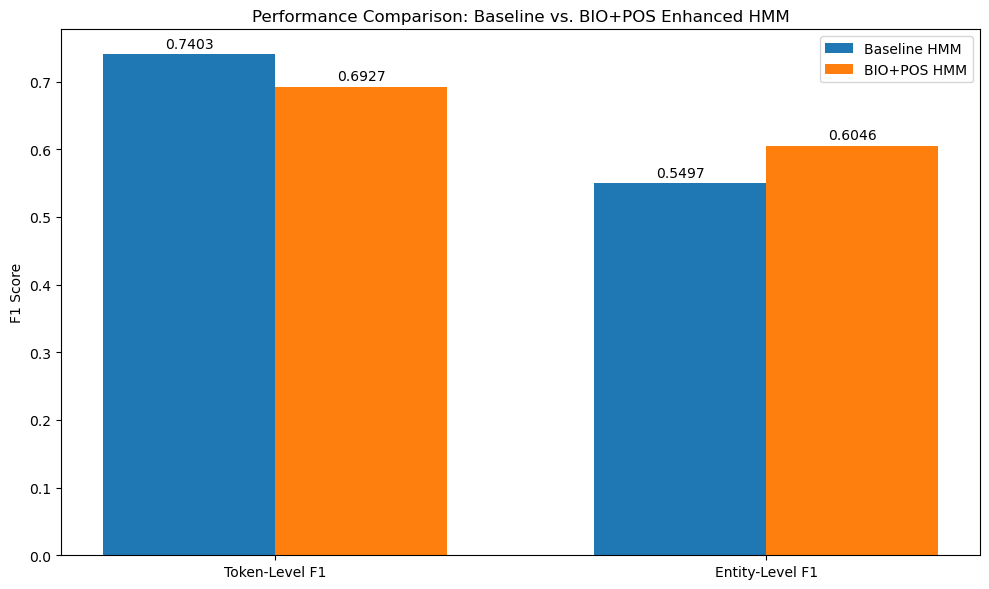

Token-level F1 improvement: -6.44%
Entity-level F1 improvement: 10.00%


In [8]:
try:
    with open(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "evaluation_baseline.json"), 'r') as f:
        baseline_metrics = json.load(f) # Load baseline metrics
        
    baseline_token_f1 = baseline_metrics["token_metrics"]["macro_avg"]["f1"]  # Get baseline token F1
    baseline_entity_f1 = baseline_metrics["entity_metrics"]["macro_avg"]["f1"]  # Get baseline entity F1
    
    bio_pos_token_f1 = metrics["macro_avg"]["f1"]  # Get BIO+POS token F1
    bio_pos_entity_f1 = entity_metrics["macro_avg"]["f1"]  # Get BIO+POS entity F1
    
    labels = ['Token-Level F1', 'Entity-Level F1']  # Chart labels
    baseline_scores = [baseline_token_f1, baseline_entity_f1]  # Baseline scores
    bio_pos_scores = [bio_pos_token_f1, bio_pos_entity_f1]  # BIO+POS scores
    
    x = np.arange(len(labels))
    width = 0.35 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, baseline_scores, width, label='Baseline HMM')  # Plot baseline
    ax.bar(x + width/2, bio_pos_scores, width, label='BIO+POS HMM')  # Plot BIO+POS
    
    ax.set_ylabel('F1 Score')
    ax.set_title('Performance Comparison: Baseline vs. BIO+POS Enhanced HMM')  # Chart title
    ax.set_xticks(x) 
    ax.set_xticklabels(labels) 
    ax.legend() 
    
    # Add values on top of bars
    for i, v in enumerate(baseline_scores):
        ax.text(i - width/2, v + 0.01, f'{v:.4f}', ha='center')
    for i, v in enumerate(bio_pos_scores):
        ax.text(i + width/2, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "bio_pos_vs_baseline.png"))
    plt.show()
    
    token_improvement = (bio_pos_token_f1 - baseline_token_f1) / baseline_token_f1 * 100  # Calculate token improvement
    entity_improvement = (bio_pos_entity_f1 - baseline_entity_f1) / baseline_entity_f1 * 100  # Calculate entity improvement
    
    print(f"Token-level F1 improvement: {token_improvement:.2f}%") 
    print(f"Entity-level F1 improvement: {entity_improvement:.2f}%") 
    
except FileNotFoundError:
    print("Baseline evaluation results not found. Run hmm_baseline.ipynb first.")

## Analyze BIO Tagging Effectiveness


In [9]:
def analyze_bio_tagging(test_states, test_predictions):
    # Convert to standard (non-BIO) tags for comparison
    std_test_states = [convert_bio_to_standard(seq) for seq in test_states]  # Convert true states
    std_test_predictions = [convert_bio_to_standard(seq) for seq in test_predictions]  # Convert predicted states
    
    # Evaluate with and without BIO tagging
    bio_metrics = get_entity_based_metrics(test_states, test_predictions, is_bio=True)  # Metrics with BIO
    std_metrics = get_entity_based_metrics(std_test_states, std_test_predictions, is_bio=False)  # Metrics without BIO
    
    print("Entity-Level F1 Scores - Comparing BIO vs Standard Evaluation:")
    print("Entity Type\tBIO Evaluation\tStandard Evaluation\tDifference")
    print("-" * 70)
    
    for label in ["NEG", "NSCO", "UNC", "USCO"]:
        bio_f1 = bio_metrics[label]["f1"]  # BIO F1 for label
        std_f1 = std_metrics[label]["f1"]  # Standard F1 for label
        diff = bio_f1 - std_f1  # Calculate difference
        
        print(f"{label}\t\t{bio_f1:.4f}\t\t{std_f1:.4f}\t\t{diff:+.4f}")

    bio_macro_f1 = bio_metrics["macro_avg"]["f1"]  # BIO macro F1
    std_macro_f1 = std_metrics["macro_avg"]["f1"]  # Standard macro F1
    macro_diff = bio_macro_f1 - std_macro_f1  # Calculate macro difference
    
    print("-" * 70)
    print(f"Macro Avg\t{bio_macro_f1:.4f}\t\t{std_macro_f1:.4f}\t\t{macro_diff:+.4f}")
    
    return bio_metrics, std_metrics

bio_metrics, std_metrics = analyze_bio_tagging(test_data["states"], test_predictions)

Entity-Level F1 Scores - Comparing BIO vs Standard Evaluation:
Entity Type	BIO Evaluation	Standard Evaluation	Difference
----------------------------------------------------------------------
NEG		0.9670		0.9655		+0.0015
NSCO		0.6077		0.6192		-0.0115
UNC		0.6568		0.6519		+0.0050
USCO		0.1871		0.1871		+0.0000
----------------------------------------------------------------------
Macro Avg	0.6046		0.6059		-0.0012


In [10]:
labels = sorted(test_data["state_space"])  # Ensure labels are sorted
flat_true_states = [tag for seq in test_data["states"] for tag in seq]
flat_pred_states = [tag for seq in test_predictions for tag in seq]

report = classification_report(flat_true_states, flat_pred_states, labels=labels, target_names=labels, digits=4)

print("Classification Report (Text Matrix):")
print(report)

Classification Report (Text Matrix):
              precision    recall  f1-score   support

       B-NEG     0.9387    0.9478    0.9432      1131
      B-NSCO     0.8228    0.8121    0.8174      1075
       B-UNC     0.6197    0.6822    0.6494       129
      B-USCO     0.5772    0.6667    0.6187       129
       I-NEG     0.4054    0.7143    0.5172        21
      I-NSCO     0.7250    0.7557    0.7400      2198
       I-UNC     0.5269    0.7538    0.6203        65
      I-USCO     0.3031    0.4208    0.3524       366
           O     0.9788    0.9717    0.9752     42776

    accuracy                         0.9514     47890
   macro avg     0.6553    0.7472    0.6927     47890
weighted avg     0.9546    0.9514    0.9529     47890



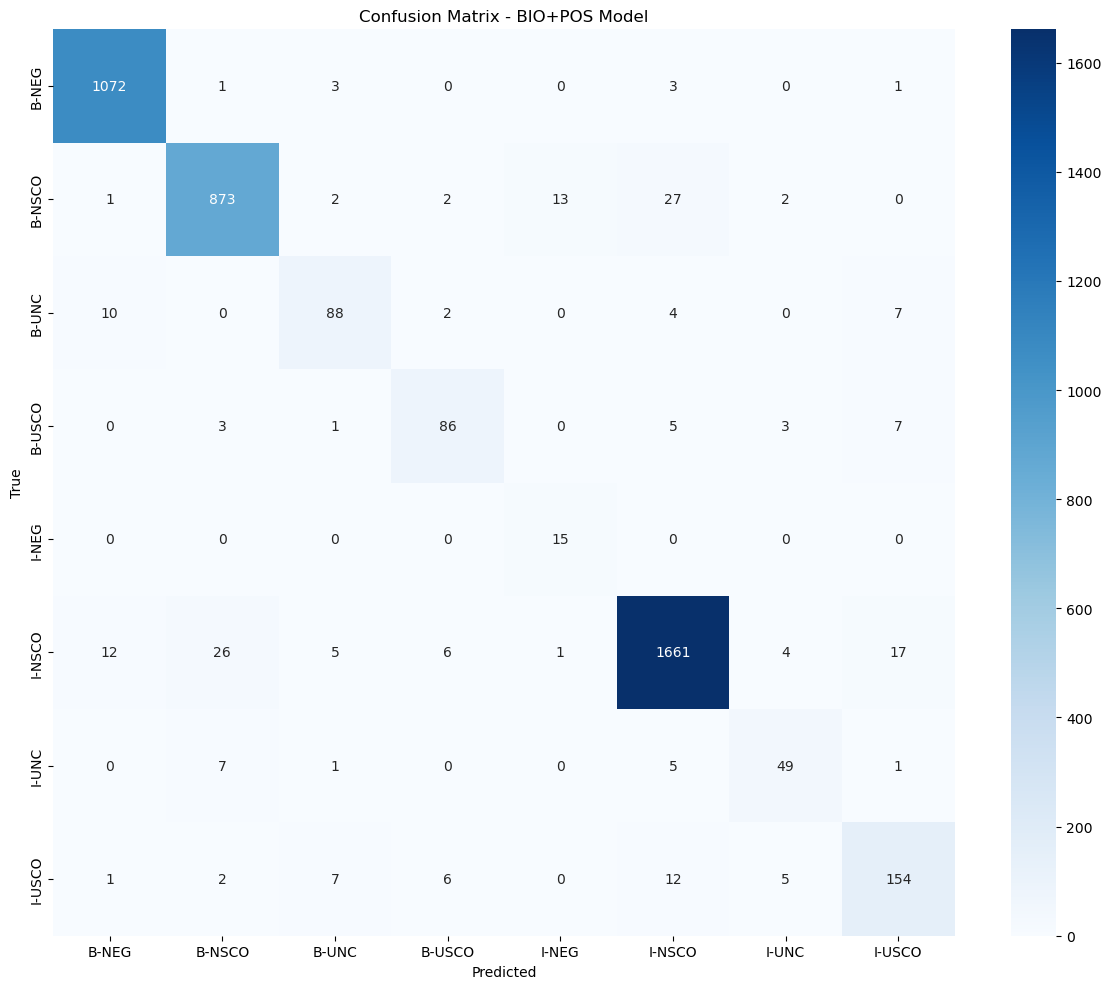

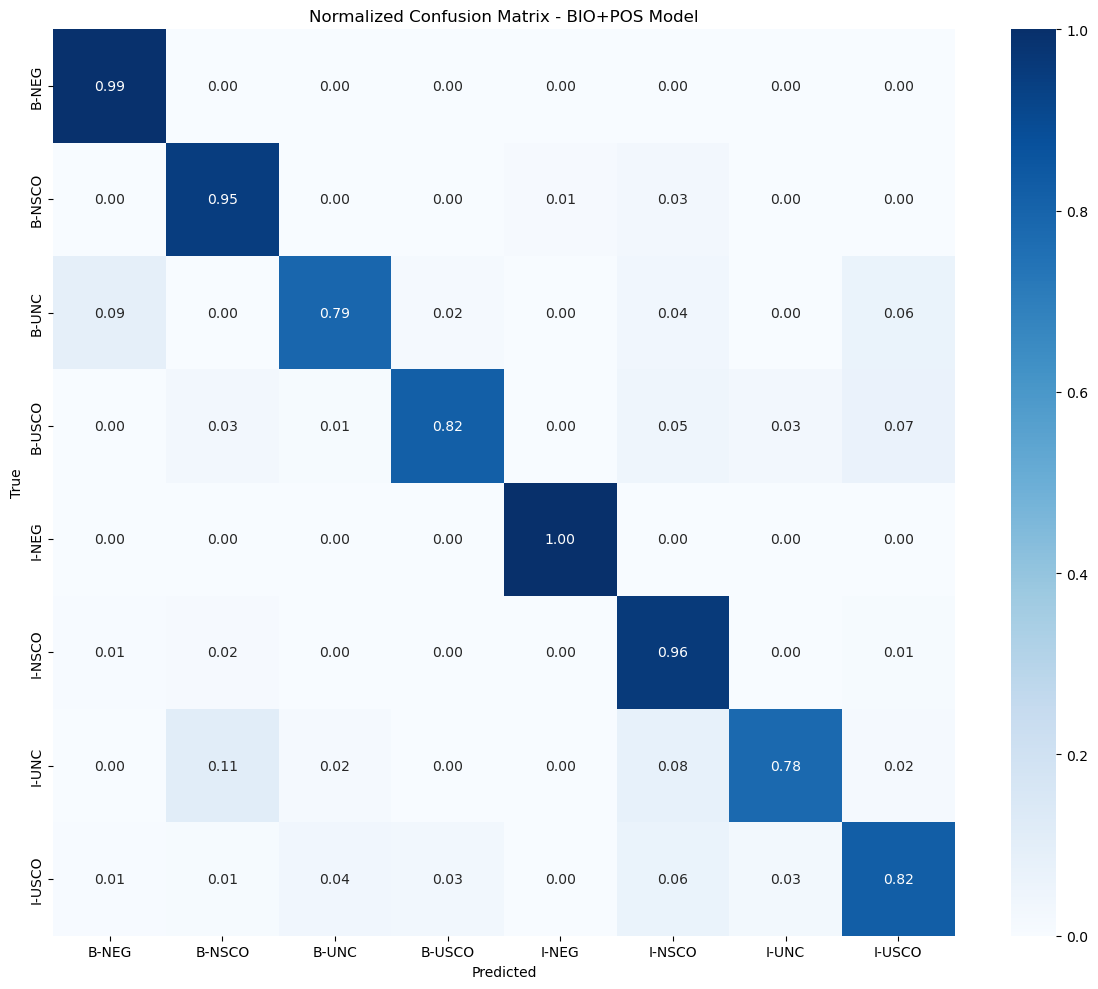

In [11]:
labels = sorted(test_data["state_space"])  # Ensure labels are sorted
flat_true_states = [tag for seq in test_data["states"] for tag in seq]
flat_pred_states = [tag for seq in test_predictions for tag in seq]

labels = [label for label in labels if label != 'O']

# Compute confusion matrix
cm = confusion_matrix(flat_true_states, flat_pred_states, labels=labels)


plt.figure(figsize=(12, 10)) # Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - BIO+POS Model')
plt.tight_layout()
plt.savefig(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "confusion_matrix_bio_pos.png"))
plt.show()

plt.figure(figsize=(12, 10)) # Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix - BIO+POS Model')
plt.tight_layout()
plt.savefig(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "confusion_matrix_bio_pos_normalized.png"))
plt.show()